### Cluster Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import datetime
import pandas_datareader as dr

In [2]:
#Import Model Packages
from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation, DBSCAN
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.metrics import adjusted_mutual_info_score
from sklearn import cluster, covariance, manifold

In [3]:
# Helper mpodules
import matplotlib.ticker as ticker
from itertools import cycle
from datetime import datetime, timedelta

In [4]:
def get_data(tickers, start_date, end_date, data_path='./data/', data_file='stock_data.csv', force_download=False, column='Close'):

    import yfinance as yf

    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, '%Y-%m-%d')

    if isinstance(end_date, str):
        end_date = datetime.strptime(end_date, '%Y-%m-%d')

    data_file = 'stock_data.csv'
    data_path = './data/'

    ## check if data directory exists to load data from there
    if not os.path.exists(data_path):
        os.makedirs(data_path)

    data_file = os.path.join(data_path, data_file)

    if os.path.exists(data_file) and not force_download:
        data = pd.read_csv(data_file, index_col=0, parse_dates=True)
        return data

    data = yf.download(tickers, start=start_date, end=end_date)[column]

    data.to_csv(data_file)

    return data


In [5]:
ticker_set = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'GOOG', 'META', 'BRKB', 'TSLA', 'UNH', 'LLY', 'JPM', 'XOM', 'JNJ', 'V', 'PG', 'AVGO', 'MA', 'HD', 'CVX', 'MRK', 'ABBV', 'PEP', 'COST', 'ADBE', 'KO', 'CSCO', 'WMT', 'TMO', 'MCD', 'PFE', 'CRM', 'BAC', 'ACN', 'CMCSA', 'LIN', 'NFLX', 'ABT', 'ORCL', 'DHR', 'AMD', 'WFC', 'DIS', 'TXN', 'PM', 'VZ', 'INTU', 'COP', 'CAT', 'AMGN', 'NEE', 'INTC', 'UNP', 'LOW', 'IBM', 'BMY', 'SPGI', 'RTX', 'HON', 'BA', 'UPS', 'GE', 'QCOM', 'AMAT', 'NKE', 'PLD', 'NOW', 'BKNG', 'SBUX', 'MS', 'ELV', 'MDT', 'GS', 'DE', 'ADP', 'LMT', 'TJX', 'T', 'BLK', 'ISRG', 'MDLZ', 'GILD', 'MMC', 'AXP', 'SYK', 'REGN', 'VRTX', 'ETN', 'LRCX', 'ADI', 'SCHW', 'CVS', 'ZTS', 'CI', 'CB', 'AMT', 'SLB', 'C', 'BDX', 'MO', 'PGR', 'TMUS', 'FI', 'SO', 'EOG', 'BSX', 'CME', 'EQIX', 'MU', 'DUK', 'PANW', 'PYPL', 'AON', 'SNPS', 'ITW', 'KLAC', 'ATVI', 'ICE', 'APD', 'SHW', 'CDNS', 'CSX', 'NOC', 'CL', 'MPC', 'HUM', 'FDX', 'WM', 'MCK', 'TGT', 'ORLY', 'HCA', 'FCX', 'EMR', 'PXD', 'MMM', 'MCO', 'ROP', 'CMG', 'PSX', 'MAR', 'PH', 'APH', 'GD', 'USB', 'NXPI', 'AJG', 'NSC', 'PNC', 'VLO', 'GBP', 'F', 'MSI', 'GM', 'TT', 'EW', 'CARR', 'AZO', 'ADSK', 'TDG', 'ANET', 'SRE', 'ECL', 'OXY', 'PCAR', 'ADM', 'MNST', 'KMB', 'PSA', 'CCI', 'CHTR', 'MCHP', 'MSCI', 'CTAS']
data_path = './data/'

In [6]:
start_date = datetime(2024, 10, 1)
end_date = datetime(2025, 10, 1)
end_analysis_date = (start_date + timedelta(days=15)).strftime("%Y-%m-%d")
end_analysis_date = datetime.strptime(end_analysis_date, "%Y-%m-%d")

In [7]:
end_analysis_date

datetime.datetime(2024, 10, 16, 0, 0)

In [9]:
dataset = get_data(ticker_set, start_date, end_date, data_path=data_path, force_download=True)

dataset.head()

/var/folders/85/5fry4xk160lfn0vlgt62q99m0000gn/T/ipykernel_93984/523806826.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)[column]
[*********************100%***********************]  174 of 174 completed

5 Failed downloads:
['PXD', 'BRKB', 'ATVI']: YFTzMissingError('possibly delisted; no timezone found')
['GBP']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-10-01 00:00:00 -> 2025-10-01 00:00:00)')
['CAT']: Timeout('Failed to perform, curl: (28) Operation timed out after 10002 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Ticker,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADM,ADP,ADSK,AJG,...,USB,V,VLO,VRTX,VZ,WFC,WM,WMT,XOM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-10-01,225.162094,188.798172,110.925453,345.618683,502.799988,219.887329,57.227818,274.356415,267.470001,284.006439,...,42.547165,275.664124,133.102463,469.760010,41.647686,54.184776,204.984344,80.485229,115.744987,192.083130
2024-10-02,225.729446,188.663986,111.003593,349.850769,505.809998,223.878677,56.525928,277.755432,270.170013,283.619568,...,42.346203,275.068298,131.369339,462.140015,41.500298,54.096733,204.382996,79.653343,117.279503,190.146713
2024-10-03,224.624573,187.350739,109.626312,354.711304,503.799988,222.728485,56.218254,278.803619,268.589996,283.768341,...,42.087818,274.929260,139.454071,453.549988,41.012062,53.783699,206.127930,79.653343,118.302513,188.694366
2024-10-04,225.749359,186.238800,110.026802,355.693207,507.220001,224.370224,56.948982,279.332611,271.160004,287.299835,...,42.776840,275.991791,137.895187,455.309998,40.698849,55.720615,205.142105,80.158417,120.474007,187.745926
2024-10-07,220.663040,185.587006,110.730103,350.351532,487.299988,222.679321,56.593231,276.354706,267.230011,284.601624,...,42.556736,271.880676,139.405640,448.600006,40.385639,55.916260,202.500076,78.336182,120.995155,185.028961


### Data Quality Check

In [10]:
print('Null Values =',dataset.isnull().values.any())

missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

Null Values = True


In [11]:
missing_fractions.head(10)

Ticker
BRKB    1.0
ATVI    1.0
CAT     1.0
GBP     1.0
PXD     1.0
ABT     0.0
ADM     0.0
ADP     0.0
ADSK    0.0
AJG     0.0
dtype: float64

In [13]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))

print('Dropping {} columns with more than 30% missing values.'.format(len(drop_list)))

dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.fillna(method='ffill', inplace=True)
dataset.fillna(method='bfill', inplace=True)

Dropping 5 columns with more than 30% missing values.


/var/folders/85/5fry4xk160lfn0vlgt62q99m0000gn/T/ipykernel_93984/2164885726.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)
/var/folders/85/5fry4xk160lfn0vlgt62q99m0000gn/T/ipykernel_93984/2164885726.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='bfill', inplace=True)


### Feature Engineering

```markdown
#### Feature Engineering for Time Series

We will create new features for each ticker:
- **Absolute Return**: Daily absolute return.
- **Volatility**: Daily return volatility.
- **Rolling Volatility**: Volatility over a rolling window (e.g., 21 days).

These features help capture price movement and risk characteristics for clustering and analysis.
```

The annualized returns calculation (returns) computes the average daily percentage change for each stock and then annualizes it by multiplying by 252 (the typical number of trading days in a year). This gives you the expected annual return for each ticker. The pct_change() method calculates day-over-day percentage changes, mean() averages these changes across the entire time period, and the multiplication by 252 scales this daily average to an annual figure.

The annualized volatility calculation (volatility) measures the risk or price variability of each stock. It takes the standard deviation of daily returns and annualizes it using the square root of time rule (multiplying by √252). This is a standard practice in finance because volatility scales with the square root of time, not linearly. Higher volatility indicates more price swings and greater investment risk.

The rolling volatility (rolling_volatility) adds a dynamic perspective by calculating volatility over 21-day rolling windows (approximately one trading month), then averaging these rolling volatilities and annualizing the result. This metric captures how consistently volatile a stock is over time, which can reveal stocks that have periods of calm followed by turbulent phases.

The return to volatility calculates the Sharpe-like ratio by creating a new feature called Return_to_Volatility, which divides each stock's annualized return by its annualized volatility. This ratio is a fundamental risk-adjusted performance metric in finance that helps identify stocks offering the best return per unit of risk taken. The return-to-volatility ratio essentially answers the question: "How much return am I getting for each unit of risk I'm taking?" 


The features.head() command displays the first few rows of the updated DataFrame, allowing you to inspect the newly calculated ratios alongside the original return, volatility, and rolling volatility features. This four-dimensional feature space (return, volatility, rolling volatility, and return-to-volatility ratio) provides a comprehensive view of each stock's risk-return characteristics, enabling more nuanced and meaningful clustering for portfolio construction and investment decision-making.


In [167]:
# Annualized Return 
annualized_returns = dataset.pct_change().mean() * 252

log_returns = np.log(dataset / dataset.shift(1)).dropna()

# Annualized Volatility
volatility = dataset.pct_change().std() * np.sqrt(252)

# 21-day rolling volatility, more stable measure to capture short-term fluctuations in volatility together with long-term volatility
rolling_volatility = dataset.pct_change().rolling(window=21).std().mean() * np.sqrt(252)

return_to_volatility = features['Return'] / features['Volatility']

features = pd.DataFrame({
    'Return': annualized_returns,
    # 'Log_Return': log_returns.mean() * 252,
    'Volatility': volatility,
    # 'Rolling_Volatility': rolling_volatility,
    # 'Return_to_Volatility': return_to_volatility
})


The log returns calculation (log_returns) uses the natural logarithm of the ratio between today's price and yesterday's price. This approach has several mathematical advantages: log returns are additive over time (meaning you can sum daily log returns to get period returns), they're symmetric around zero (a 10% gain followed by a 10% loss nets to approximately zero), and they assume continuous compounding. Log returns also tend to be more normally distributed, which is beneficial for many statistical models and clustering algorithms. The dropna() removes the first row which becomes NaN due to the shift operation.

The annualized returns calculation (annualized_returns) uses simple percentage changes via pct_change(), takes the mean of these daily returns, and multiplies by 252 trading days to annualize the result. This approach gives you intuitive percentage returns that are easier to interpret and communicate to stakeholders. For example, "this stock returned 15% annually" is more immediately understandable than discussing log returns.

For clustering purposes, the choice matters because log returns often produce more stable and statistically robust results due to their superior mathematical properties, especially when dealing with volatile stocks or longer time periods. However, if you prioritize interpretability and want clusters that align with common investment thinking (like "high-return stocks" in percentage terms), annualized returns might be more appropriate. Many quantitative finance applications favor log returns for modeling and analysis, then convert back to percentage terms for presentation and decision-making.

In [150]:
# should we use log return or annulized return for clustering?
log_returns = np.log(dataset / dataset.shift(1)).dropna()

annualized_returns = dataset.pct_change().mean() * 252



In [151]:
features.head()

,Return,Volatility
Ticker,,
AAPL,0.176412,0.324869
ABBV,0.239801,0.282046
ABT,0.210277,0.218219
ACN,-0.302259,0.279488
ADBE,-0.301205,0.333266


The sns.pairplot(features) generates a matrix of scatter plots where each feature (Return, Volatility, Rolling_Volatility, etc.) is plotted against every other feature. Along the diagonal, you'll see histograms showing the distribution of each individual feature. This comprehensive view allows you to quickly identify correlations, outliers, and distribution patterns across all your financial metrics simultaneously.

The scatter plots in the off-diagonal positions reveal important relationships between features. For example, you might observe that high-return stocks tend to have higher volatility (positive correlation), or that certain stocks cluster together in specific risk-return profiles. These visual patterns provide valuable insights into how your features relate to each other and can help validate whether your chosen metrics capture distinct aspects of stock behavior.

This visualization serves as a sanity check before clustering - it helps you verify that your features show meaningful variation and relationships. If all stocks looked identical across these metrics, clustering would be pointless. The pairplot also helps identify potential issues like highly correlated features (which might be redundant) or extreme outliers that could skew your clustering results, allowing you to make informed decisions about feature selection and data preprocessing.

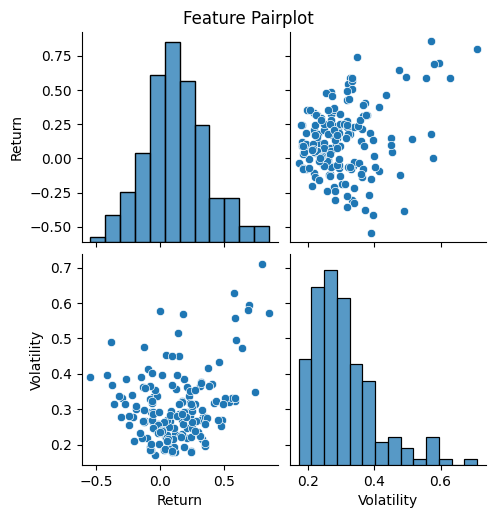

In [152]:
## visualise the features for sanity check
sns.pairplot(features)
plt.suptitle('Feature Pairplot', y=1.02)
plt.show()

In [153]:
scaler = StandardScaler().fit(features)
rescaled_features = pd.DataFrame(scaler.transform(features), columns=features.columns, index=features.index)

In [154]:
rescaled_features

,Return,Volatility
Ticker,,
AAPL,0.201819,0.194735
ABBV,0.453169,-0.243068
ABT,0.336102,-0.895598
ACN,-1.696210,-0.269213
ADBE,-1.692031,0.280584
...,...,...
WFC,1.450378,0.102848
WM,-0.133033,-1.255818
WMT,0.607688,-0.679604


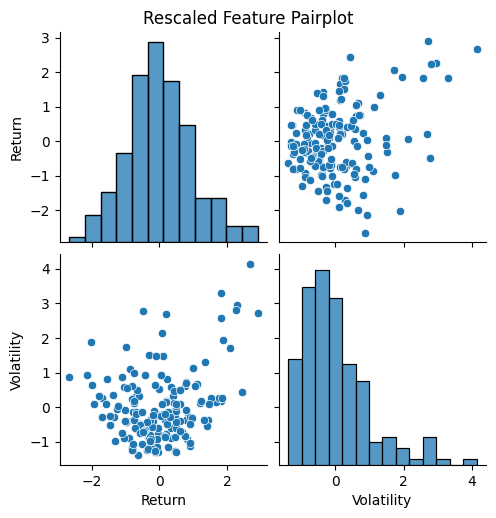

In [155]:
## Visualise the rescaled features
sns.pairplot(rescaled_features)
plt.suptitle('Rescaled Feature Pairplot', y=1.02)
plt.show()

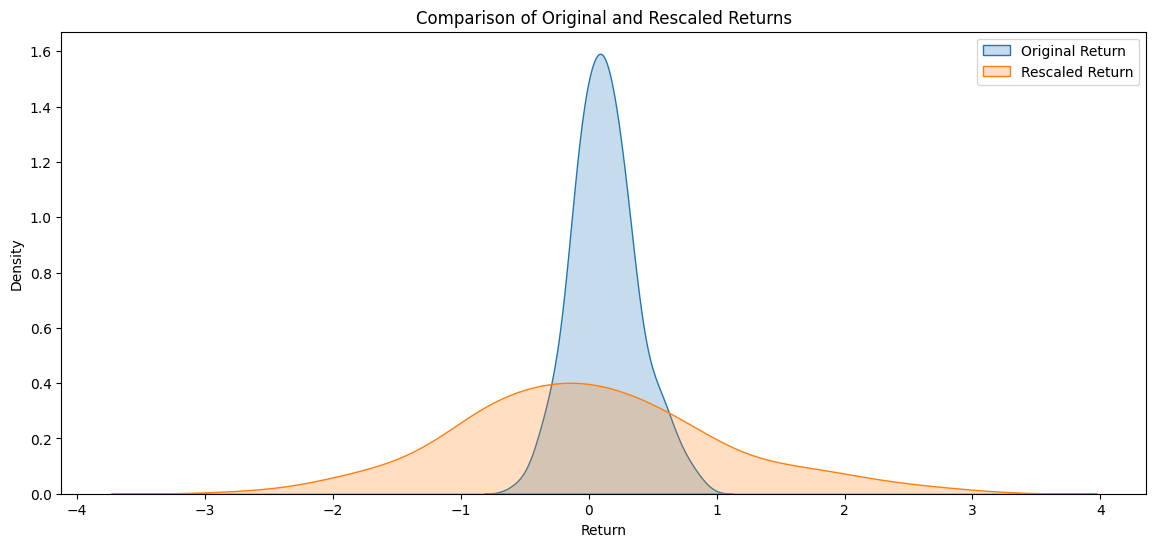

In [156]:
plt.figure(figsize=(14, 6))
sns.kdeplot(data=features['Return'], label='Original Return', fill=True)
sns.kdeplot(data=rescaled_features['Return'], label='Rescaled Return', fill=True)
plt.title('Comparison of Original and Rescaled Returns')
plt.legend()
plt.show()

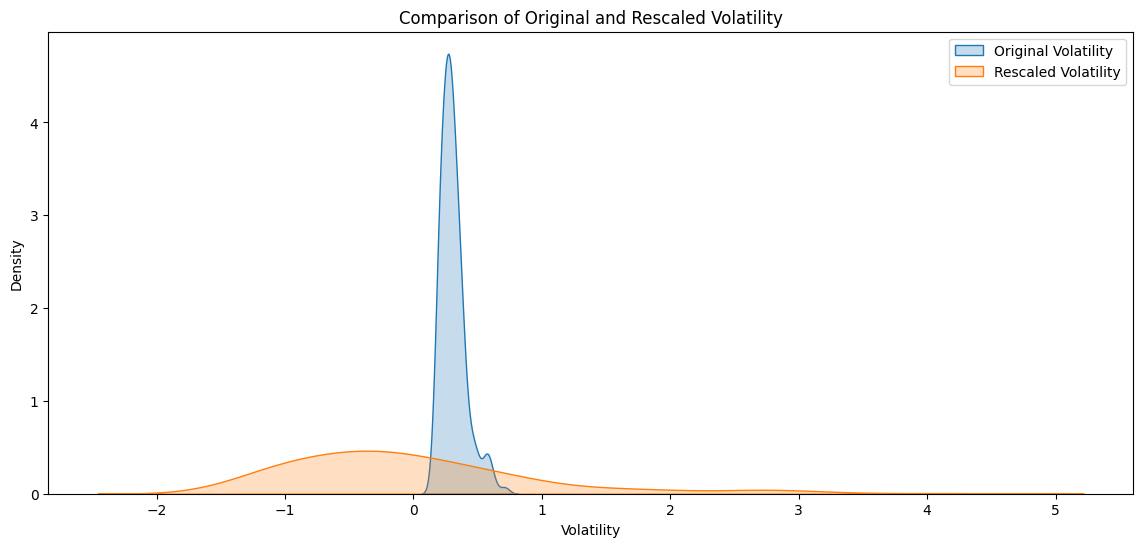

In [157]:
plt.figure(figsize=(14, 6))
sns.kdeplot(data=features['Volatility'], label='Original Volatility', fill=True)
sns.kdeplot(data=rescaled_features['Volatility'], label='Rescaled Volatility', fill=True)
plt.title('Comparison of Original and Rescaled Volatility')
plt.legend()
plt.show()

In [158]:
# plt.figure(figsize=(14, 6))
# sns.kdeplot(data=features['Rolling_Volatility'], label='Original Rolling Volatility', fill=True)
# sns.kdeplot(data=rescaled_features['Rolling_Volatility'], label='Rescaled Rolling Volatility', fill=True)
# plt.title('Comparison of Original and Rescaled Rolling Volatility')
# plt.legend()
# plt.show()

In [121]:
# plt.figure(figsize=(14, 6))
# sns.kdeplot(data=features['Log_Return'], label='Original Log Return', fill=True)
# sns.kdeplot(data=rescaled_features['Log_Return'], label='Rescaled Log Return', fill=True)
# plt.title('Comparison of Original and Rescaled Log Return')
# plt.legend()
# plt.show()

In [142]:
# plt.figure(figsize=(14, 6))
# sns.kdeplot(data=features['Return_to_Volatility'], label='Original Return to Volatility', fill=True)
# sns.kdeplot(data=rescaled_features['Return_to_Volatility'], label='Rescaled Return to Volatility', fill=True)
# plt.title('Comparison of Original and Rescaled Return to Volatility')
# plt.legend()
# plt.show()

### Cluster Analysis

Implementing Elbow Method, a fundamental technique for determining the optimal number of clusters in K-means clustering. It systematically evaluates different cluster configurations to help to make an informed decision about how many groups your stock data should be divided into.

The main loop iterates through different cluster counts from 2 to 19 (max_loop=20). For each k value, it creates a new K-means model, fits it to your stock data, and records the inertia_ - a measure of how tightly grouped the data points are within their assigned clusters. Lower inertia indicates that stocks within each cluster are more similar to each other, which generally suggests better clustering quality.

The visualization creates a line plot showing how inertia decreases as the number of clusters increases. This typically produces a characteristic "elbow" shape where the rate of inertia reduction slows dramatically at a certain point. The elbow point represents the optimal number of clusters - beyond this point, adding more clusters provides diminishing returns in terms of improving the grouping quality.



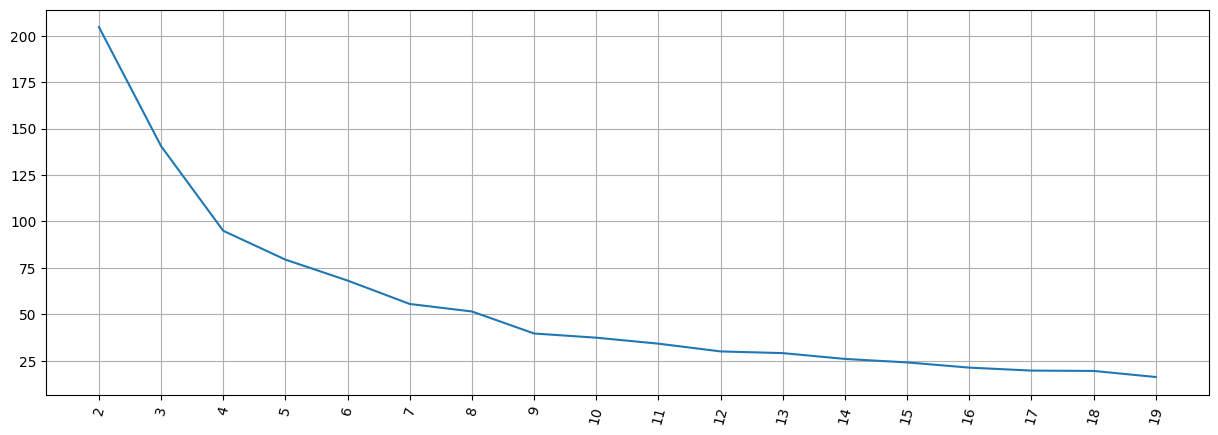

In [159]:
X=rescaled_features

distorsions = []
max_loop=20
for k in range(2, max_loop):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    distorsions.append(kmeans.inertia_)
fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, max_loop), distorsions)
plt.xticks([i for i in range(2, max_loop)], rotation=75)
plt.grid(True)

This code implements the Silhouette Analysis method, which provides a complementary approach to the Elbow Method for determining the optimal number of clusters. While the Elbow Method focuses on within-cluster tightness, silhouette analysis evaluates both how well-separated different clusters are and how cohesive each individual cluster is.

The silhouette score measures the quality of clustering by calculating how similar each data point is to its own cluster compared to other clusters. For each stock, it computes the average distance to all other stocks in the same cluster (cohesion) versus the average distance to stocks in the nearest neighboring cluster (separation). The silhouette score ranges from -1 to +1, where values closer to +1 indicate excellent clustering, values near 0 suggest overlapping clusters, and negative values indicate that stocks may be assigned to the wrong clusters. This gives you a single quality metric for each clustering configuration, making it easy to compare different numbers of clusters objectively.

We are looking for a peak score which represents the optimal clustering configuration.

Unlike the Elbow Method which looks for a bend in the curve, silhouette analysis provides a clear maximum value to target. The combination of both methods gives you confidence in your cluster selection - the elbow point should align reasonably well with high silhouette scores for a robust clustering solution.

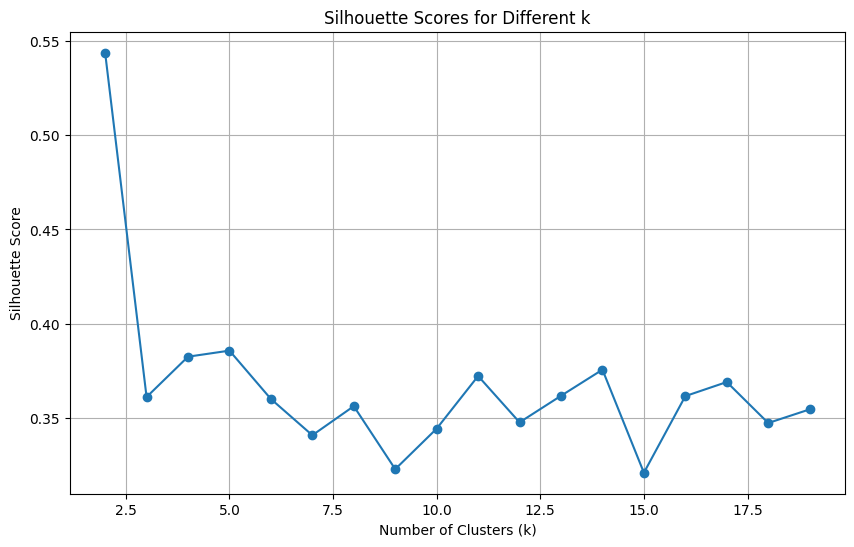

In [160]:
## Implement silhouette analysis to find the optimal number of clusters and visualise the results to discover the best k
silhouette_scores = []
for k in range(2, max_loop):
    kmeans = KMeans(n_clusters=k)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = metrics.silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Visualize the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_loop), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

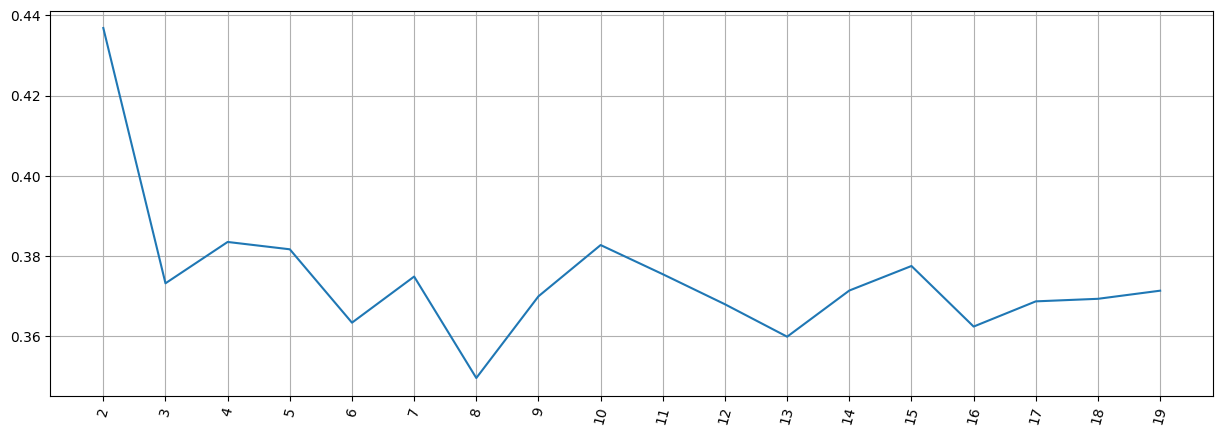

In [162]:
silhouette_score = []
for k in range(2, max_loop):
    kmeans = KMeans(n_clusters=k,  random_state=10, n_init=10)
    kmeans.fit(X)
    silhouette_score.append(metrics.silhouette_score(X, kmeans.labels_, random_state=10))
fig = plt.figure(figsize=(15, 5))
plt.plot(range(2, max_loop), silhouette_score)
plt.xticks([i for i in range(2, max_loop)], rotation=75)
plt.grid(True)
plt.show()

The np.argmax(silhouette_scores) function finds the index position of the maximum silhouette score in your scores array. Since Python uses zero-based indexing but your clustering analysis started with k=2 clusters (not k=0), you need to add 2 to convert the array index back to the actual number of clusters. For example, if the maximum score occurs at index 3 in your array, that corresponds to k=5 clusters (3 + 2 = 5).

The best_score = silhouette_scores[best_k - 2] line retrieves the actual silhouette score value that corresponds to the optimal number of clusters. The subtraction of 2 is necessary because you're indexing back into the zero-based array - if your best k is 5, you need to access index 3 (5 - 2 = 3) to get the correct score.

In [161]:
# Calculate the best silhouette score and the corresponding number of clusters
best_k = np.argmax(silhouette_scores) + 2  # +2 because range starts at 2
best_score = silhouette_scores[best_k - 2]
print(f'Best number of clusters: {best_k} with silhouette score: {best_score:.4f}')

Best number of clusters: 2 with silhouette score: 0.5436


In [163]:
### Based on the elbow method and silhouette scores, we choose k=4
nclust=8

#Fit with k-means
k_means = cluster.KMeans(n_clusters=nclust)
k_means.fit(X)
target_labels = k_means.predict(X)
centroids = k_means.cluster_centers_


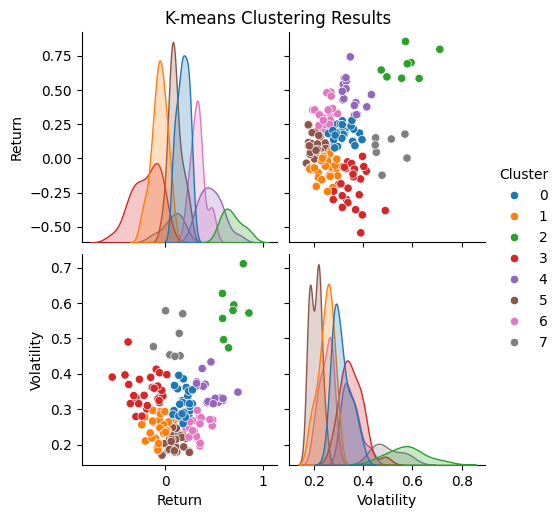

In [164]:
## Visualise k_means cluster results for all features with pairplot
### Target labels added to original features for better interpretability. Target labels represent cluster assignments from K-means. 

features['Cluster'] = target_labels
sns.pairplot(features, hue='Cluster', palette='tab10')
plt.suptitle('K-means Clustering Results', y=1.02)
plt.show()

In [168]:
results = features.copy()
results['Kmeans_Cluster'] = target_labels

rescaled_results = rescaled_features.copy()
rescaled_results['Kmeans_Cluster'] = target_labels

In [169]:
rescaled_results.head()

,Return,Volatility,Kmeans_Cluster
Ticker,,,
AAPL,0.201819,0.194735,0
ABBV,0.453169,-0.243068,0
ABT,0.336102,-0.895598,5
ACN,-1.696210,-0.269213,3
ADBE,-1.692031,0.280584,3


In [170]:
X = rescaled_results.copy()

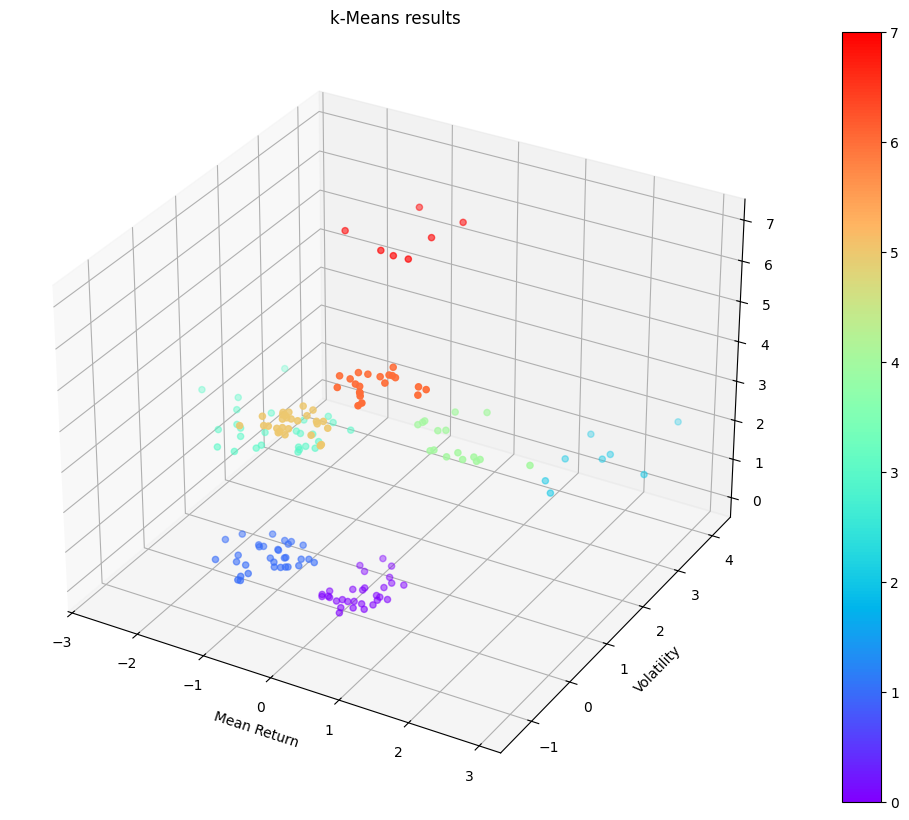

In [172]:
### Visualise k_means cluster results for all features with 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X.iloc[:,0],X.iloc[:,1], X.iloc[:,2], c = k_means.labels_, cmap ="rainbow", label = X.index)
ax.set_title('k-Means results')
ax.set_xlabel('Mean Return')
ax.set_ylabel('Volatility')
# ax.set_zlabel('Rolling Volatility')
plt.colorbar(scatter)

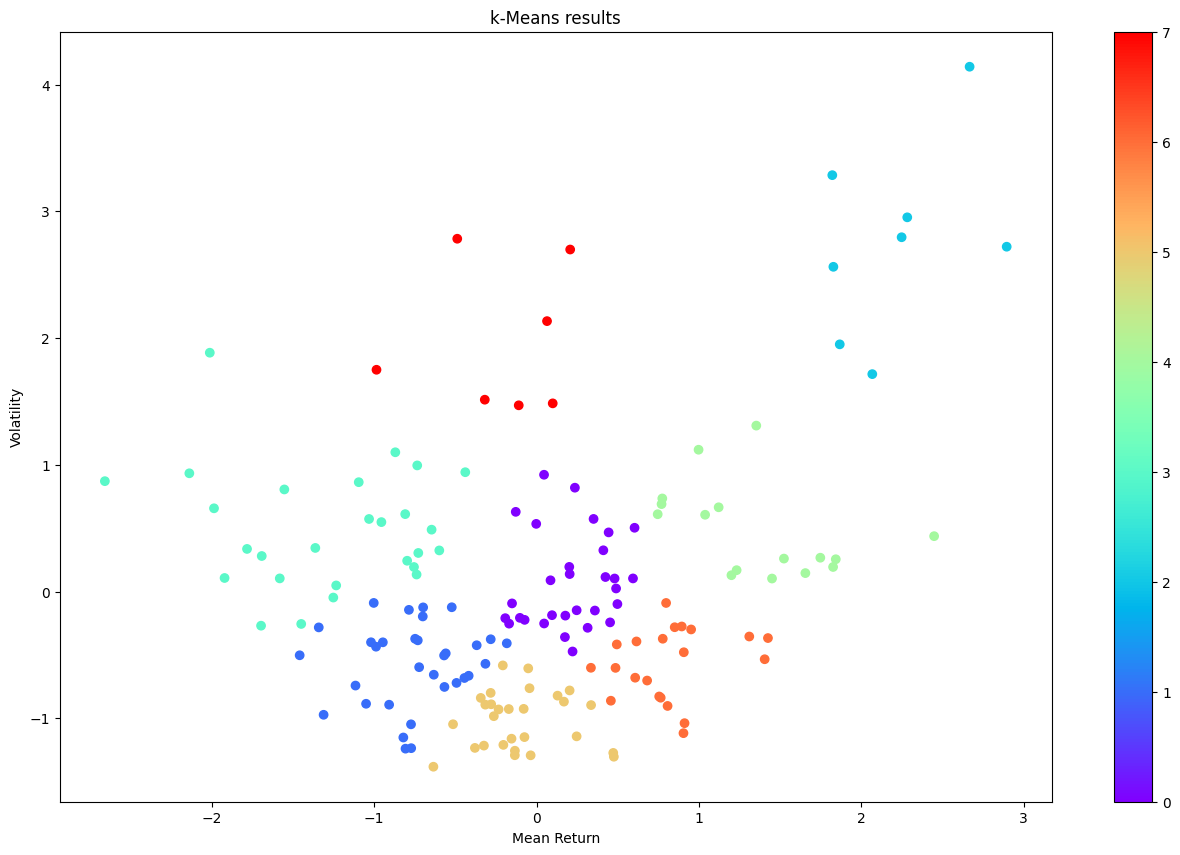

In [173]:
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
scatter = ax.scatter(X.iloc[:,0],X.iloc[:,1], c = k_means.labels_, cmap ="rainbow", label = X.index)
ax.set_title('k-Means results')
ax.set_xlabel('Mean Return')
ax.set_ylabel('Volatility')
plt.colorbar(scatter)

In [174]:
# ## Visualise number of stocks in each cluster
# cluster_counts = features['Cluster'].value_counts().sort_index()
# plt.figure(figsize=(10, 6))
# sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
# plt.title('Number of Stocks in Each Cluster')
# plt.xlabel('Cluster')
# plt.ylabel('Number of Stocks')
# plt.show()


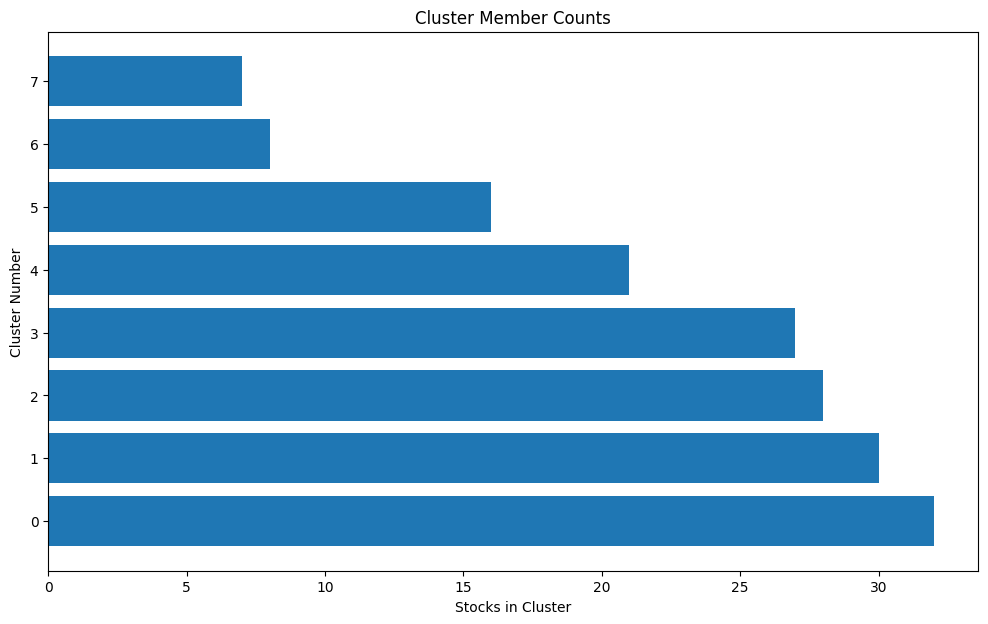

In [175]:
# show number of stocks in each cluster
clustered_series = pd.Series(index=X.index, data=k_means.labels_.flatten())
# clustered stock with its cluster label
clustered_series_all = pd.Series(index=X.index, data=k_means.labels_.flatten())
clustered_series = clustered_series[clustered_series != -1]

plt.figure(figsize=(12,7))
plt.barh(
    range(len(clustered_series.value_counts())), # cluster labels, y axis
    clustered_series.value_counts()
)
plt.title('Cluster Member Counts')
plt.xlabel('Stocks in Cluster')
plt.ylabel('Cluster Number')
plt.show()

In [176]:
### calculate cluster statistics
cluster_stats = rescaled_results.groupby('Kmeans_Cluster').agg(['mean', 'std', 'min', 'max', 'count'])
cluster_stats  

Return                                     Volatility  \
                    mean       std       min       max count       mean   
Kmeans_Cluster                                                            
0               0.211646  0.238525 -0.192398  0.603838    30   0.072373   
1              -0.751438  0.309836 -1.458444 -0.183009    32  -0.576973   
2               2.209932  0.399975  1.821553  2.895478     8   2.765741   
3              -1.278147  0.570116 -2.658090 -0.438636    27   0.486012   
4               1.358203  0.469681  0.746360  2.448629    16   0.480973   
5              -0.100674  0.274343 -0.634910  0.476326    28  -1.016295   
6               0.816379  0.291142  0.335152  1.425302    21  -0.572931   
7              -0.218454  0.417459 -0.985372  0.207401     7   1.976562   

                                                    
                     std       min       max count  
Kmeans_Cluster                                      
0               0.368720 -0.472752  0.921744    30  
1               0.322170 -1.239426 -0.089598    32  
2               0.756719  1.715755  4.141287     8  
3               0.470092 -0.269213  1.884690    27  
4               0.362822  0.102848  1.309553    16  
5               0.224105 -1.382005 -0.582593    28  
6               0.278259 -1.117208 -0.089851    21  
7               0.571882  1.469695  2.784044     7

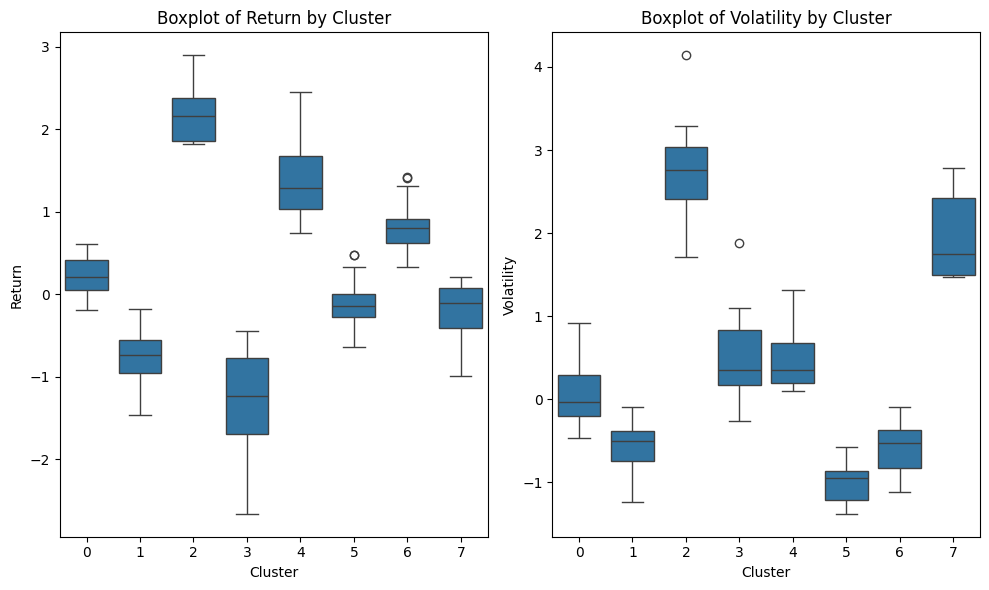

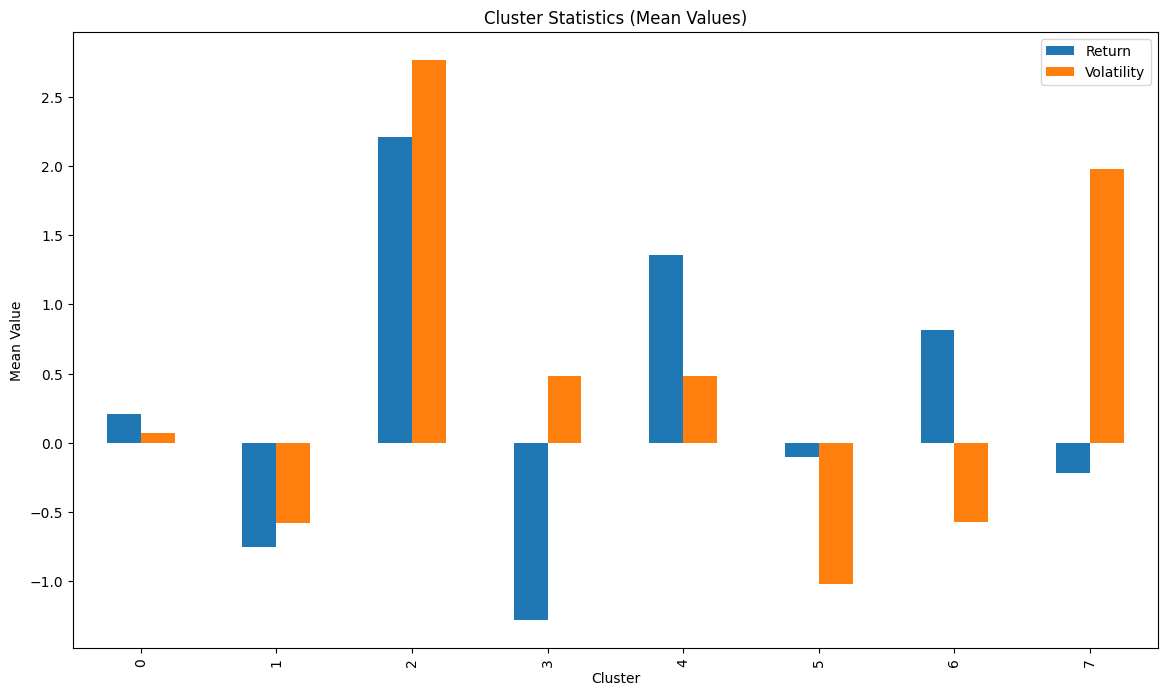

In [177]:
### Visualise cluster statistics for every feature with subplots
feature_names = rescaled_results.columns[:-1]  # Exclude the cluster label column
num_features = len(feature_names)
fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(5*num_features, 6))
for i, feature in enumerate(feature_names):
    sns.boxplot(x='Kmeans_Cluster', y=feature, data=rescaled_results, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feature)
plt.tight_layout()
plt.show()

### Visualise cluster statistics for every feature
cluster_stats_plot = cluster_stats.xs('mean', level=1, axis=1)
cluster_stats_plot.plot(kind='bar', figsize=(14, 8))
plt.title('Cluster Statistics (Mean Values)')
plt.xlabel('Cluster')
plt.ylabel('Mean Value')
plt.show()

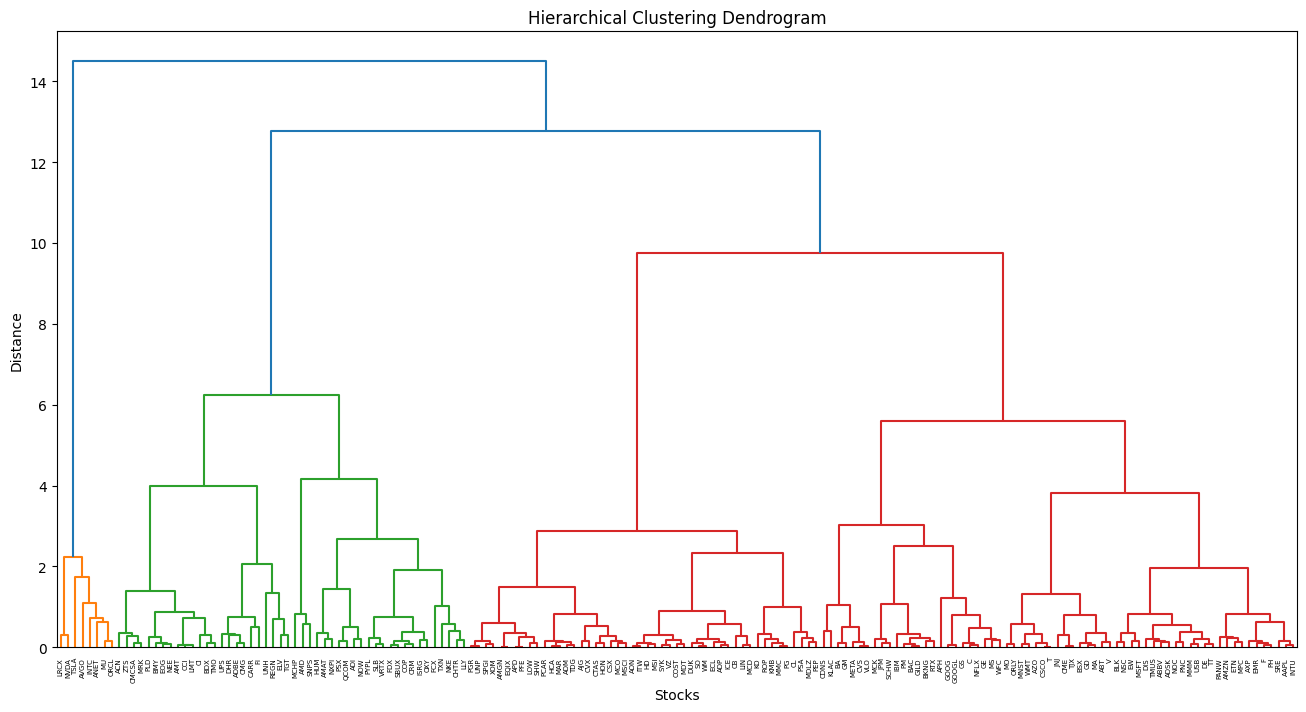

In [178]:

#Calulate linkage matrix
Z = linkage(X.iloc[:,:-1], 'ward')  
#Plot dendrogram
plt.figure(figsize=(16, 8))
dendrogram(Z, labels=X.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Stocks')
plt.ylabel('Distance')
plt.show()

## Hierarchical clustering

This code implements hierarchical clustering using the Ward linkage method, which provides an alternative approach to K-means clustering for grouping stocks based on their risk-return characteristics. Unlike K-means, hierarchical clustering doesn't require you to specify the number of clusters upfront - instead, it builds a tree-like structure that reveals natural groupings at different levels of similarity.

The linkage(X, method='ward') function creates a linkage matrix that encodes the hierarchical clustering process. The Ward method minimizes the variance within clusters when merging, making it particularly effective for financial data where you want tight, cohesive groups. The print(Z[0]) displays the first row of this matrix, showing the initial merge between the two most similar stocks along with their distance and the size of the resulting cluster.

The dendrogram visualization is the key strength of hierarchical clustering - it shows the entire clustering hierarchy as a tree structure. Each stock starts as its own cluster at the bottom, and as you move up the tree, similar stocks are progressively merged based on their proximity in the risk-return feature space. The height at which branches merge indicates the dissimilarity between clusters, allowing you to visually identify natural breakpoints where clusters should be separated.

The distance_threshold = 13 represents a horizontal cut through the dendrogram at a specific height. This threshold determines how many clusters you'll end up with - cutting at a lower height produces more clusters (tighter groups), while cutting higher produces fewer, broader clusters. The fcluster() function applies this cut and assigns each stock to a cluster number, creating the final grouping.


This approach is particularly valuable for financial portfolio construction because it reveals the hierarchical relationships between stocks. You can see not just which stocks belong together, but also how different groups relate to each other at various levels of similarity. This multi-level view helps in creating diversified portfolios by understanding which stocks are most closely related and which represent truly independent investment themes.



[4.30000000e+01 1.47000000e+02 1.35649792e-02 2.00000000e+00]


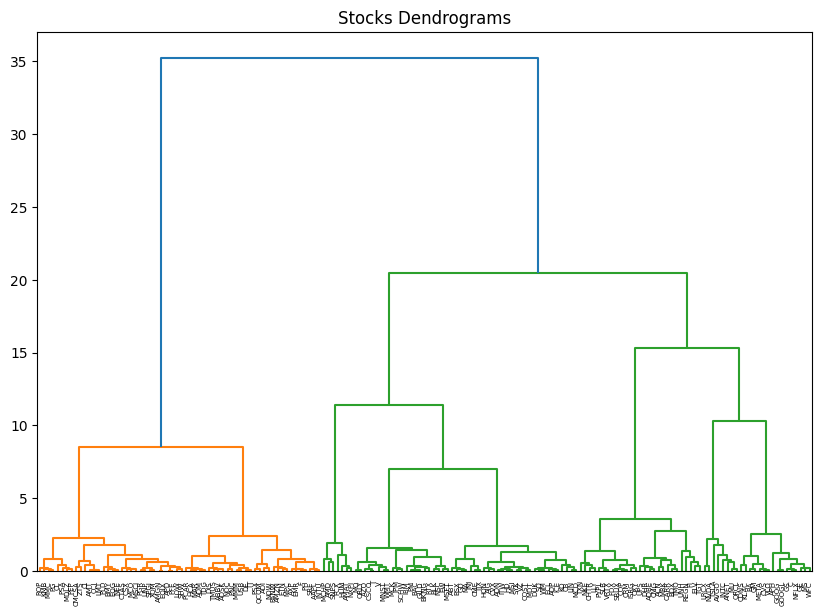

[1 2 3 4]


In [179]:
Z= linkage(X, method='ward')
print(Z[0])
#Plot Dendogram
plt.figure(figsize=(10, 7))
plt.title("Stocks Dendrograms")
dendrogram(Z,labels = X.index)
plt.show()
distance_threshold = 13
clusters = fcluster(Z, distance_threshold, criterion='distance')
chosen_clusters = pd.DataFrame(data=clusters, columns=['cluster'])
print(chosen_clusters['cluster'].unique())

This code implements agglomerative hierarchical clustering with a predefined number of clusters, providing a more controlled approach to hierarchical clustering compared to the dendrogram-based threshold method. By setting hc_nclust = 4, you're explicitly specifying that you want exactly four clusters, which allows for direct comparison with your K-means results and ensures consistent portfolio segmentation.

The AgglomerativeClustering object uses the Ward linkage method with Euclidean distance, which is the same approach as the previous hierarchical clustering but with a fixed cluster count. The Ward method minimizes within-cluster variance when merging clusters, making it particularly effective for financial data where you want cohesive risk-return groups. The fit_predict(X) method performs the entire clustering process and returns cluster labels in one step, making it more streamlined than the dendrogram approach.

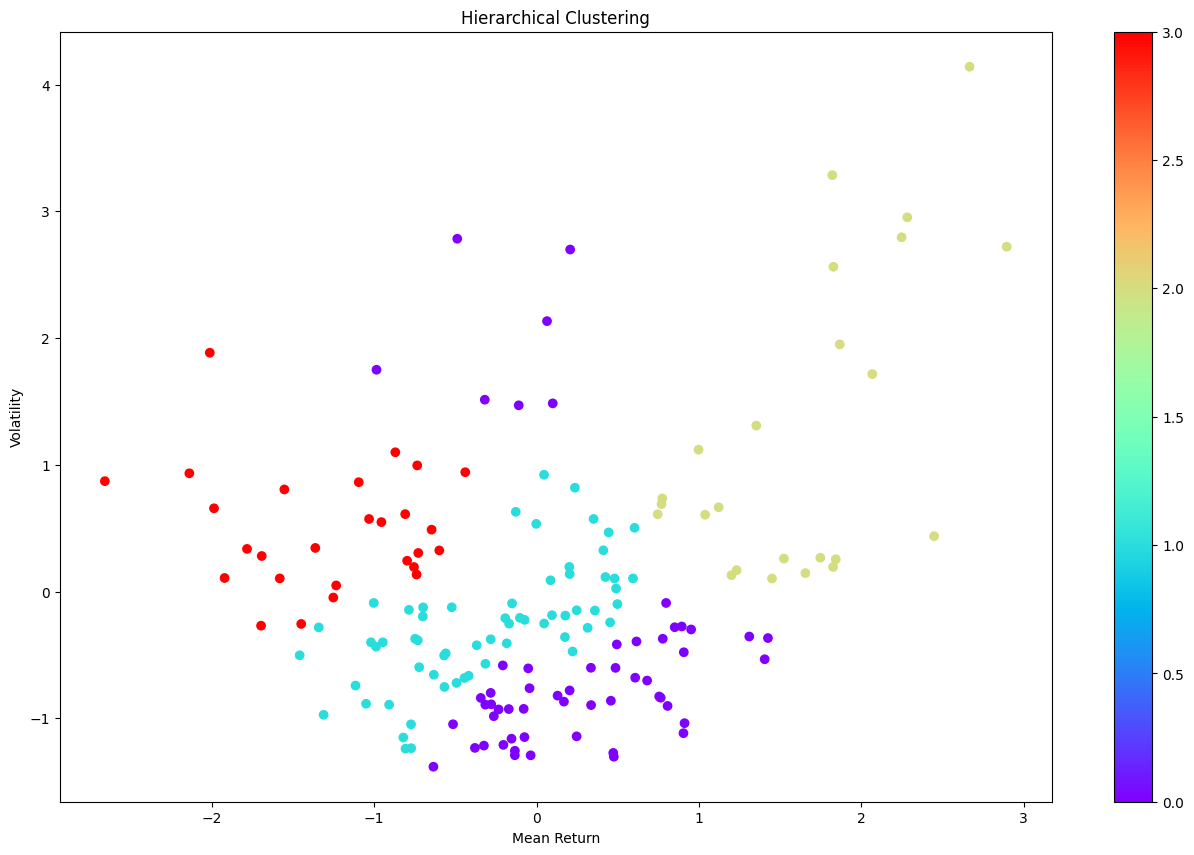

In [181]:
hc_nclust = 4
hc = AgglomerativeClustering(n_clusters=hc_nclust, metric = 'euclidean', linkage = 'ward')
clust_labels1 = hc.fit_predict(X)
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)
scatter = ax.scatter(X.iloc[:,0],X.iloc[:,1], c =clust_labels1, cmap ="rainbow")
ax.set_title('Hierarchical Clustering')
ax.set_xlabel('Mean Return')
ax.set_ylabel('Volatility')
plt.colorbar(scatter)


This code implements Affinity Propagation clustering, a fundamentally different approach from K-means and hierarchical clustering that automatically determines the optimal number of clusters without requiring you to specify it upfront. This makes it particularly valuable for financial data analysis where the natural number of market segments or investment categories may not be obvious beforehand.

The AffinityPropagation() algorithm works by treating each stock as a potential cluster exemplar and iteratively passing messages between data points to identify the most representative stocks that should serve as cluster centers. Unlike K-means which uses mathematical centroids, Affinity Propagation selects actual stocks from your dataset as exemplars, meaning each cluster is represented by a real company rather than an abstract mathematical point. This provides more interpretable results for portfolio management since you can identify specific stocks that best represent each investment category.

The algorithm's automatic cluster detection is both a strength and potential challenge for financial applications. While it eliminates the guesswork of choosing cluster counts, it may produce more or fewer clusters than desired for practical portfolio construction. The number of clusters depends on the algorithm's internal similarity calculations and preference parameters, which can result in highly granular segmentation that might need consolidation for investment purposes.



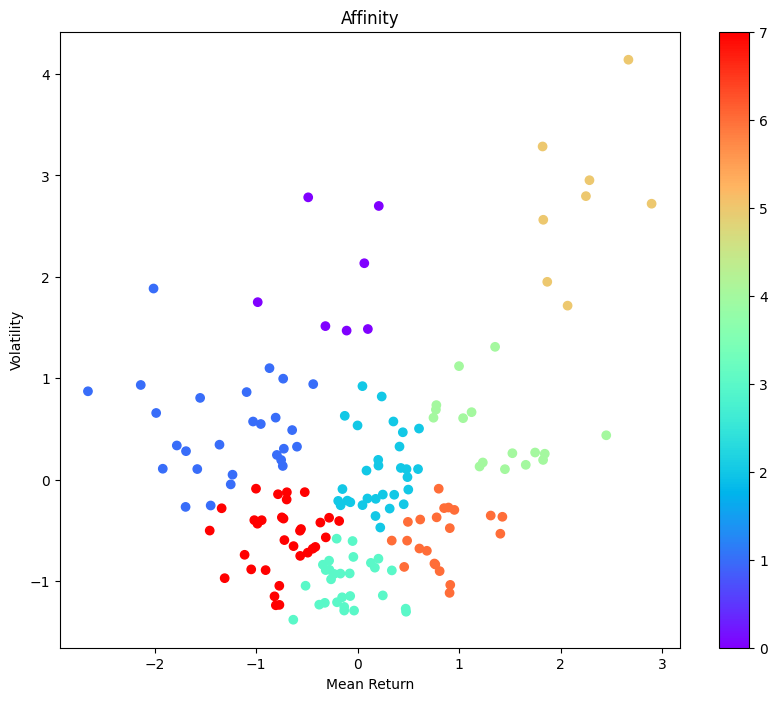

In [182]:
ap = AffinityPropagation()
ap.fit(X)
clust_labels2 = ap.predict(X)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
scatter = ax.scatter(X.iloc[:,0],X.iloc[:,1], c =clust_labels2, cmap ="rainbow")
ax.set_title('Affinity')
ax.set_xlabel('Mean Return')
ax.set_ylabel('Volatility')
plt.colorbar(scatter)

This code extracts and analyzes the key results from the Affinity Propagation clustering algorithm, providing essential information about the automatically discovered cluster structure in your stock data. Unlike K-means or hierarchical clustering where you pre-define the number of clusters, Affinity Propagation determines this organically based on the inherent patterns in your financial features.

The ap.cluster_centers_indices_ attribute contains the indices of exemplar stocks - these are the actual companies from your dataset that the algorithm has identified as the most representative of each cluster. This is a unique feature of Affinity Propagation: instead of mathematical centroids, you get real stocks that serve as prototypes for each investment category. For example, if Apple (AAPL) is selected as an exemplar, it means other stocks in that cluster share similar risk-return characteristics with Apple and can be considered part of the same investment theme.

In [184]:
cluster_centers_indices = ap.cluster_centers_indices_
labels = ap.labels_

no_clusters = len(cluster_centers_indices)
print('Estimated number of clusters: %d' % no_clusters)
# Plot exemplars

Estimated number of clusters: 8


In [190]:
### Visualise exemplars for each cluster in subplots for a single stock time series
# print(cluster_vis_list[0:min(len(cluster_vis_list), 4)])
# for clust in cluster_vis_list[0:min(len(cluster_vis_list), 4)]:
#     tickers = list(clustered_series[clustered_series==clust].index)
#     means = np.log(dataset.loc[:end_analysis_date].mean())
#     data = np.log(dataset.loc[:end_analysis_date]).sub(means)
#     data.plot(title='Stock Time Series for Cluster %d' % clust)
# plt.show()


This code creates a sophisticated visualization of the Affinity Propagation clustering results that clearly shows both the cluster structure and the relationships between exemplar stocks and their cluster members. The visualization goes beyond simple scatter plots by drawing explicit connections between each stock and its representative exemplar, providing immediate insight into how the algorithm has organized your financial data.

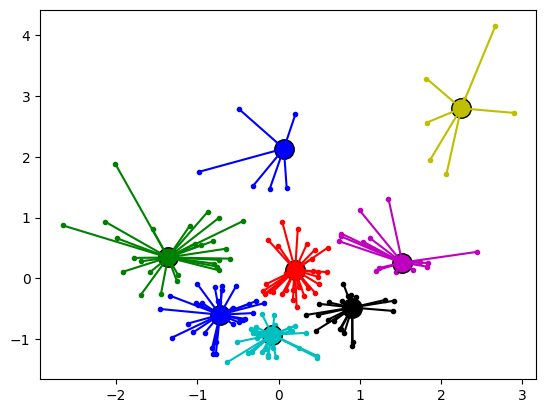

In [191]:
X_temp=np.asarray(X)
plt.close('all')
plt.figure(1)
plt.clf()

colors = cycle('bgrcmykbgrcmykbgrcmykbgrcmyk')
for k, col in zip(range(no_clusters), colors):
    class_members = labels == k
    cluster_center = X_temp[cluster_centers_indices[k]]
    plt.plot(X_temp[class_members, 0], X_temp[class_members, 1], col + '.')
    plt.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col, markeredgecolor='k', markersize=14)
    for x in X_temp[class_members]:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], col)

plt.show()


This code creates a cluster size analysis for the Affinity Propagation clustering results, providing crucial insights into how the algorithm has distributed stocks across the automatically determined clusters. Understanding cluster sizes is essential for portfolio construction because it reveals whether the clustering has created balanced, actionable investment categories or produced highly uneven groupings that might need consolidation.

The code begins by creating two pandas Series objects that map each stock ticker to its assigned cluster label. The clustered_series_ap and clustered_series_all_ap both contain identical mappings from stock indices to cluster numbers, created by flattening the ap.labels_ array. This redundancy suggests preparation for different analytical purposes - the "all" version likely preserves all cluster assignments including potential outliers, while the filtered version will exclude problematic classifications.

The filtering step clustered_series_ap = clustered_series_ap[clustered_series != -1] removes any stocks assigned to cluster -1, which in many clustering algorithms represents outliers or noise points that couldn't be confidently assigned to any cluster. However, there's a potential issue here: the filter references clustered_series instead of clustered_series_ap, which suggests this might be filtering based on a different clustering result (possibly from a previous analysis), rather than the current Affinity Propagation results.

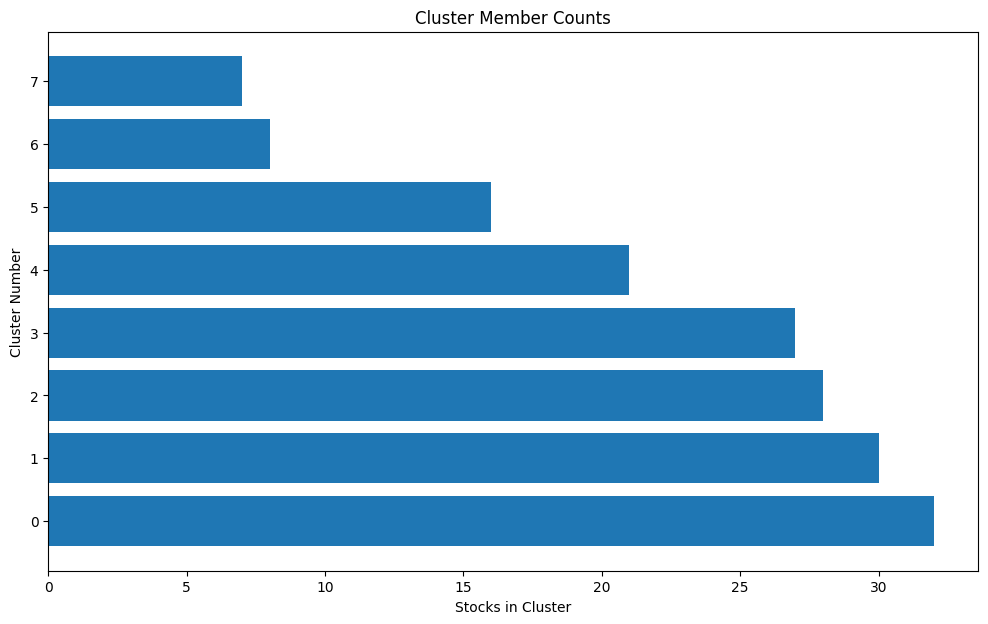

In [192]:
# show number of stocks in each cluster
clustered_series_ap = pd.Series(index=X.index, data=ap.labels_.flatten())
# clustered stock with its cluster label
clustered_series_all_ap = pd.Series(index=X.index, data=ap.labels_.flatten())
clustered_series_ap = clustered_series_ap[clustered_series != -1]

plt.figure(figsize=(12,7))
plt.barh(
    range(len(clustered_series_ap.value_counts())), # cluster labels, y axis
    clustered_series_ap.value_counts()
)
plt.title('Cluster Member Counts')
plt.xlabel('Stocks in Cluster')
plt.ylabel('Cluster Number')
plt.show()

In [193]:
### Cluster Algorithms Comparison Summary
# K-means, Hierarchical Clustering, Affinity Propagation
comparison_df = pd.DataFrame({
    'KMeans_Labels': k_means.labels_,
    'Hierarchical_Labels': clust_labels1,
    'Affinity_Labels': clust_labels2
}, index=X.index)

<Axes: title={'center': 'Cluster Assignments Comparison'}, xlabel='Ticker'>

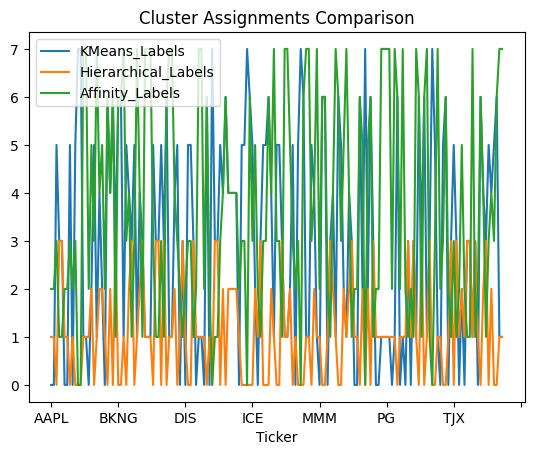

In [ ]:
### Visualise K-means, Hierarchical Clustering, Affinity Propagation comparision to compare cluster assignments together with seaborn pairplot

This code performs a comparative evaluation of three different clustering algorithms applied to your stock data by calculating their respective silhouette scores. The silhouette score is a crucial metric for assessing clustering quality, as it measures both how well-separated the clusters are from each other and how cohesive each individual cluster is internally. This comparison allows you to determine which clustering approach produces the most meaningful groupings for your financial analysis.

The first line evaluates K-means clustering using k_means.labels_, which contains the pre-computed cluster assignments from your earlier K-means analysis. Since K-means was already fitted to the data, you can directly access the stored labels without re-running the algorithm. The silhouette score will reveal how well the K-means algorithm has separated stocks into distinct risk-return categories and whether stocks within each cluster are truly similar to each other.

The second line evaluates hierarchical clustering, but with an important difference: it calls hc.fit_predict(X) rather than using pre-stored labels. This means the hierarchical clustering algorithm is being re-executed during the evaluation, which could potentially lead to slightly different results if there's any randomness in the algorithm or if the data has been modified since the original clustering. This approach ensures you're getting the most current hierarchical clustering results for comparison.

The third line evaluates Affinity Propagation using ap.labels_, similar to the K-means approach. Since Affinity Propagation automatically determines the number of clusters, this comparison will show whether the algorithm's data-driven cluster count produces better internal cohesion and separation compared to the fixed cluster counts used in K-means and hierarchical clustering.



In [102]:
print("km", metrics.silhouette_score(X, k_means.labels_, metric='euclidean'))
print("hc", metrics.silhouette_score(X, hc.fit_predict(X), metric='euclidean'))
print("ap", metrics.silhouette_score(X, ap.labels_, metric='euclidean'))

km 0.42207965579210294
hc 0.3368866669106809
ap 0.37228064017127527


This code segment performs post-processing of Affinity Propagation clustering results to prepare the data for further analysis and visualization. The code creates multiple Series objects that map stock tickers to their assigned cluster labels, with different filtering approaches to handle potential outliers or noise points that the algorithm couldn't confidently assign to any cluster.

In [197]:
# all stock with its cluster label (including -1)
clustered_series = pd.Series(index=X.index, data=ap.fit_predict(X).flatten())
# clustered stock with its cluster label
clustered_series_all = pd.Series(index=X.index, data=ap.fit_predict(X).flatten())
clustered_series = clustered_series[clustered_series != -1]
# get the number of stocks in each cluster
counts = clustered_series_ap.value_counts()


This code segment performs cluster filtering and pair analysis preparation for your stock clustering results, focusing on identifying clusters that are optimal for pairs trading analysis. The code systematically filters clusters based on size constraints to ensure you're working with meaningful groups that contain enough stocks for statistical analysis while avoiding clusters that are too large to be practically useful.

The first filtering operation creates cluster_vis_list by selecting clusters that contain between 2 and 24 stocks ((counts<25) & (counts>1)). This range is strategically chosen because clusters with only one stock are meaningless for pairs analysis (you need at least two stocks to form a pair), while clusters with 25 or more stocks might be too broad and dilute the similarity that clustering is meant to capture. The [::-1] reverses the list order, likely to prioritize smaller clusters for visualization since they're often more cohesive and easier to interpret.

The second filtering step applies a much broader size constraint with CLUSTER_SIZE_LIMIT = 9999, effectively including almost all multi-stock clusters ((counts>1) & (counts<=CLUSTER_SIZE_LIMIT)). This creates ticker_count_reduced, which represents the final set of clusters that will be used for comprehensive pairs analysis. The extremely high limit suggests this is meant to be inclusive rather than restrictive, ensuring that only singleton clusters are excluded from the analysis.

The pairs calculation (ticker_count_reduced*(ticker_count_reduced-1)).sum() computes the total number of potential stock pairs that need to be evaluated across all viable clusters. For each cluster with n stocks, there are n×(n-1) possible ordered pairs (or n×(n-1)/2 unique unordered pairs). This calculation is crucial for understanding the computational complexity of the subsequent cointegration analysis, as each pair will need to be tested for statistical relationships that could support pairs trading strategies.

This systematic approach to cluster filtering is essential for quantitative finance applications because it balances statistical rigor with computational practicality. By focusing on appropriately sized clusters, you ensure that pairs trading analysis will be performed on stocks that are genuinely similar (due to clustering) while maintaining enough variety within each cluster to find meaningful statistical relationships. The size constraints prevent both overfitting (from tiny clusters) and noise (from oversized clusters) that could undermine the effectiveness of your pairs trading strategy.


In [198]:
# let's visualize some clusters
cluster_vis_list = list(counts[(counts<25) & (counts>1)].index)[::-1]
print(cluster_vis_list)

CLUSTER_SIZE_LIMIT = 9999
counts = clustered_series.value_counts()
ticker_count_reduced = counts[(counts>1) & (counts<=CLUSTER_SIZE_LIMIT)]
print ("Clusters formed: %d" % len(ticker_count_reduced))
print ("Pairs to evaluate: %d" % (ticker_count_reduced*(ticker_count_reduced-1)).sum())
# plot a handful of the smallest clusters

[0, 5, 4, 6]
Clusters formed: 8
Pairs to evaluate: 4078


In [106]:
# print(cluster_vis_list[0:min(len(cluster_vis_list), 4)])
# for clust in cluster_vis_list[0:min(len(cluster_vis_list), 4)]:
#     tickers = list(clustered_series[clustered_series==clust].index)
#     means = np.log(dataset.loc[:end_analysis_date].mean())
#     data = np.log(dataset.loc[:end_analysis_date]).sub(means)
#     data.plot(title='Stock Time Series for Cluster %d' % clust)
# plt.show()

In [199]:
### Finding pairs of cointegrated stocks within each cluster for pairs trading strategy

This function implements cointegration testing for pairs trading, a sophisticated statistical method used to identify stocks that maintain a long-term equilibrium relationship despite short-term price divergences. Cointegration is a fundamental concept in quantitative finance that allows traders to identify pairs of stocks whose prices move together over time, even if they occasionally drift apart temporarily.

The core functionality revolves around the coint() function from statsmodels, which performs the Engle-Granger cointegration test. This test determines whether two time series have a stationary linear combination, meaning that while the individual stock prices may trend upward or downward over time, the spread between them tends to revert to a stable mean. The function takes two stock price series and returns a test statistic and p-value that indicate the strength of the cointegration relationship.

The function creates two output matrices to store comprehensive results. The score_matrix stores the cointegration test statistics, where more negative values typically indicate stronger cointegration relationships. The pvalue_matrix stores the statistical significance of each test, where values below the significance threshold (default 0.05) suggest that the null hypothesis of no cointegration can be rejected. These matrices provide a complete picture of all pairwise relationships in your stock universe.

The practical application for pairs trading is straightforward: when the function identifies a cointegrated pair (p-value < 0.05), it suggests that temporary price divergences between these stocks are likely to revert to their historical relationship. This creates trading opportunities where you can buy the underperforming stock and short the outperforming one, profiting when their prices converge back to equilibrium. The significance parameter allows you to control the statistical confidence required before considering a pair suitable for trading.

In [200]:

from statsmodels.tsa.stattools import coint

def find_cointegrated_pairs(data, significance=0.05):
    # This function is from https://www.quantopian.com/lectures/introduction-to-pairs-trading
    n = data.shape[1]
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < significance:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

This code implements a systematic cluster-based cointegration analysis that applies pairs trading discovery within each individual cluster rather than across the entire stock universe. This approach is strategically sound because stocks within the same cluster already share similar risk-return characteristics from the clustering analysis, making them more likely to exhibit the long-term equilibrium relationships that cointegration testing seeks to identify.

The main processing loop iterates through each viable cluster identified in ticker_count_reduced.index, which contains clusters that passed the earlier size filtering (having more than one stock but fewer than the maximum limit). For each cluster, the code extracts the ticker symbols of all stocks assigned to that cluster using clustered_series[clustered_series == which_clust].index, then calls the find_cointegrated_pairs() function on the price data for just those stocks. This cluster-by-cluster approach is computationally more efficient than testing all possible pairs in the entire dataset and focuses the analysis on stocks that are already deemed similar by the clustering algorithm.

The results storage structure uses a nested dictionary (cluster_dict) that preserves the complete cointegration analysis for each cluster. For each cluster ID, it stores three key components: the cointegration test scores (score_matrix), the statistical significance values (pvalue_matrix), and the list of statistically significant pairs (pairs). This comprehensive storage allows for later analysis of cointegration strength patterns within specific investment themes or sector groupings, and enables you to understand not just which pairs are cointegrated, but how strong those relationships are within each cluster.

The aggregation phase combines all discovered cointegrated pairs from every cluster into a single master list. The code iterates through all clusters in the dictionary and extends the main pairs list with each cluster's cointegrated pairs using pairs.extend(). This creates a comprehensive collection of all statistically validated pairs across the entire stock universe, while maintaining the benefit of having discovered them through focused, cluster-specific analysis.

The summary statistics provide immediate insight into the effectiveness of the cluster-based approach. The first print statement shows the total number of cointegrated pairs discovered across all clusters, indicating the scale of potential pairs trading opportunities. The second print statement uses np.unique(pairs) to count how many individual stocks participate in at least one cointegrated relationship, which helps assess the coverage and diversification potential of the discovered pairs. This cluster-based methodology typically produces higher-quality pairs because the clustering pre-selects stocks with similar characteristics, increasing the likelihood that their price relationships will be stable and mean-reverting over time.

In [201]:
cluster_dict = {}
for i, which_clust in enumerate(ticker_count_reduced.index):
    tickers = clustered_series[clustered_series == which_clust].index
    score_matrix, pvalue_matrix, pairs = find_cointegrated_pairs(
        dataset[tickers]
    )
    cluster_dict[which_clust] = {}
    cluster_dict[which_clust]['score_matrix'] = score_matrix
    cluster_dict[which_clust]['pvalue_matrix'] = pvalue_matrix
    cluster_dict[which_clust]['pairs'] = pairs

pairs = []
for clust in cluster_dict.keys():
    pairs.extend(cluster_dict[clust]['pairs'])

print ("Number of pairs found : %d" % len(pairs))
print ("In those pairs, there are %d unique tickers." % len(np.unique(pairs)))
print(pairs)

Number of pairs found : 130
In those pairs, there are 110 unique tickers.
[('AMT', 'MDLZ'), ('APD', 'EOG'), ('APD', 'UNP'), ('CCI', 'CTAS'), ('CTAS', 'MDLZ'), ('EOG', 'PFE'), ('EOG', 'UNP'), ('KMB', 'MMC'), ('KMB', 'PGR'), ('KMB', 'ROP'), ('LMT', 'PSA'), ('MSCI', 'NEE'), ('MSCI', 'PEP'), ('MSCI', 'PFE'), ('MSCI', 'PG'), ('MSCI', 'PGR'), ('MSCI', 'PLD'), ('MSCI', 'PSA'), ('MSCI', 'ROP'), ('MSCI', 'SHW'), ('MSCI', 'UNP'), ('MSCI', 'XOM'), ('MSCI', 'ZTS'), ('NEE', 'PGR'), ('NEE', 'ROP'), ('NEE', 'SHW'), ('NEE', 'XOM'), ('PG', 'ZTS'), ('PSA', 'XOM'), ('PSA', 'ZTS'), ('ADI', 'MPC'), ('ADM', 'F'), ('ADSK', 'AXP'), ('ADSK', 'ETN'), ('ADSK', 'MPC'), ('ADSK', 'PNC'), ('ADSK', 'SRE'), ('ADSK', 'USB'), ('MPC', 'NOC'), ('NOW', 'TMUS'), ('PANW', 'PH'), ('PANW', 'PNC'), ('PANW', 'PSX'), ('PANW', 'QCOM'), ('PANW', 'SRE'), ('PANW', 'TT'), ('PANW', 'USB'), ('QCOM', 'SRE'), ('QCOM', 'USB'), ('SRE', 'USB'), ('ADP', 'BSX'), ('ADP', 'CME'), ('ADP', 'COST'), ('ADP', 'CVX'), ('ADP', 'GD'), ('ADP', 'HD'), ('A

This code creates an advanced visualization of cointegrated stock pairs using t-SNE (t-distributed Stochastic Neighbor Embedding) dimensionality reduction to reveal the spatial relationships between stocks that have been validated for pairs trading. The visualization transforms high-dimensional financial feature data into a 2D space where similar stocks appear closer together, making it easier to understand the clustering patterns and pair relationships that were discovered through the cointegration analysis.

The data preparation phase begins by extracting all unique stocks that participate in at least one cointegrated pair using np.unique(pairs). The code then restructures the feature data by creating X_df as a transposed DataFrame and filtering it to include only the stocks that are part of validated pairs (X_pairs). This focused approach ensures the visualization concentrates on the most relevant stocks rather than displaying all stocks in the dataset, making the resulting plot more interpretable and actionable for trading decisions.

The t-SNE transformation applies dimensionality reduction with carefully tuned parameters: learning_rate=50 for stable convergence, perplexity=3 for local neighborhood preservation, and random_state=1337 for reproducible results. The low perplexity value is particularly important because it's designed to work well with smaller datasets of validated pairs, ensuring that the algorithm captures meaningful local relationships between cointegrated stocks rather than global structure that might not be relevant for pairs trading.

However, there's a critical bug in the pair connection drawing loop. The line ticker2 = pair[0] should be ticker2 = pair[1] - currently, it's drawing connections from each stock to itself rather than to its actual pair partner. This error would result in no visible connecting lines between paired stocks, significantly reducing the visualization's effectiveness.

The visual elements work together to tell a comprehensive story about the pairs trading opportunities. The scatter plot colors each stock according to its cluster membership using in_pairs_series.values and the cm.Paired colormap, allowing you to see how clustering and cointegration results align. The gray connecting lines (when the bug is fixed) will show which specific stocks are cointegrated with each other, while the stock ticker annotations provide immediate identification. The green square markers representing cluster centroids help you understand how the pairs relate to the overall clustering structure, providing context for whether pairs are within clusters or bridge across

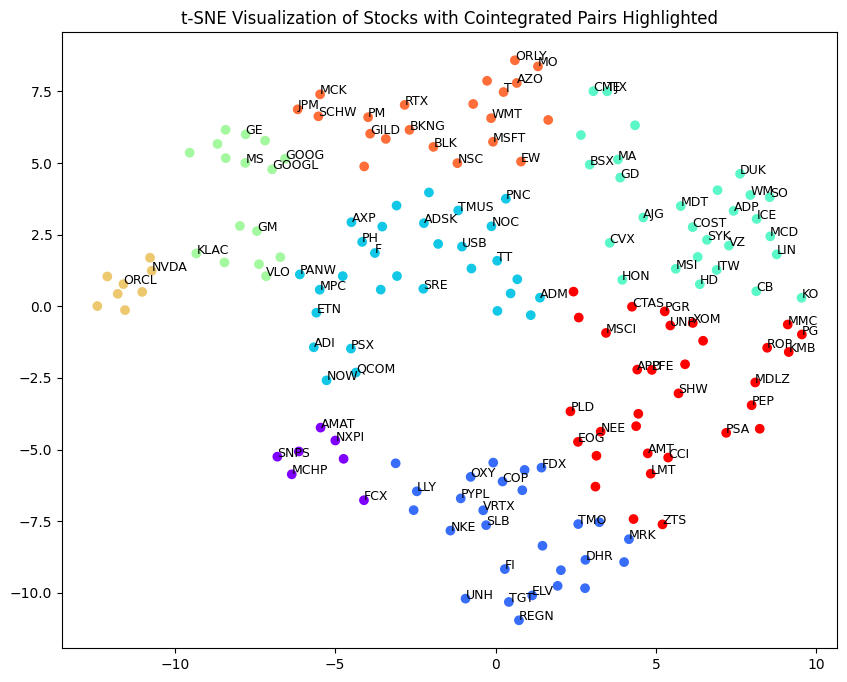

In [203]:
### Create visualisation for cointegrated stock pairs using t-SNE dimensionality reduction
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X.iloc[:,:-1])
plt.figure(figsize=(10,8))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=ap.labels_, cmap='rainbow')
for i, ticker in enumerate(X.index):
    if any(ticker in pair for pair in pairs):
        plt.annotate(ticker, (X_tsne[i,0], X_tsne[i,1]), fontsize=9)
plt.title('t-SNE Visualization of Stocks with Cointegrated Pairs Highlighted')
plt.show()  

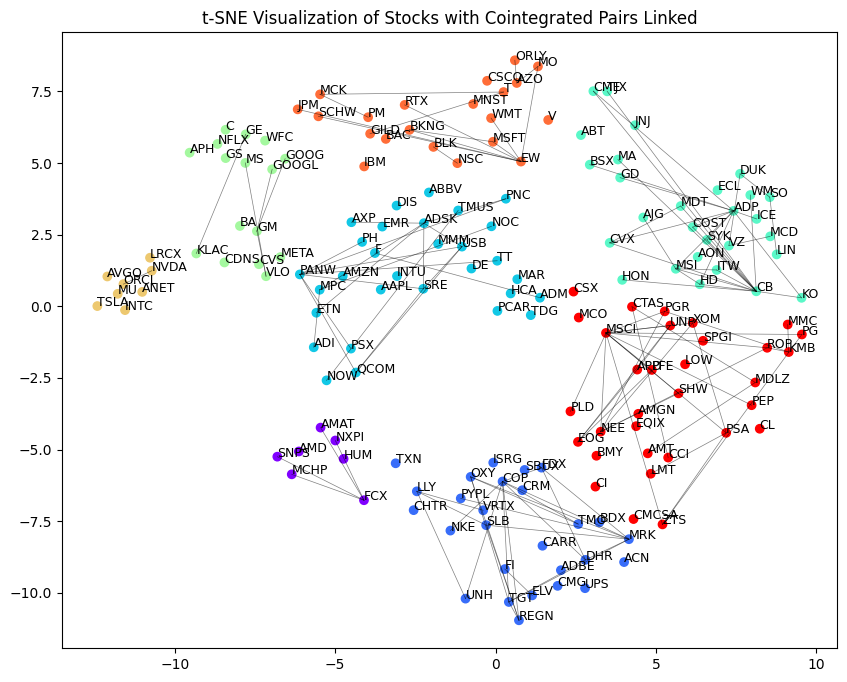

In [205]:
### Create visualisation for cointegrated stock pairs using t-SNE dimensionality reduction linking together with lines for cointegrated pairs
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X.iloc[:,:-1])
plt.figure(figsize=(10,8))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=ap.labels_, cmap='rainbow')
for i, ticker in enumerate(X.index):
    plt.annotate(ticker, (X_tsne[i,0], X_tsne[i,1]), fontsize=9)
# Draw lines for cointegrated pairs
for pair in pairs:
    ticker1, ticker2 = pair
    if ticker1 in X.index and ticker2 in X.index:
        idx1 = X.index.get_loc(ticker1)
        idx2 = X.index.get_loc(ticker2)
        plt.plot([X_tsne[idx1,0], X_tsne[idx2,0]], [X_tsne[idx1,1], X_tsne[idx2,1]], 'k-', lw=0.5, alpha=0.5)   
plt.title('t-SNE Visualization of Stocks with Cointegrated Pairs Linked')
plt.show()

/var/folders/85/5fry4xk160lfn0vlgt62q99m0000gn/T/ipykernel_93984/2764414324.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  plt.plot([x1, x2], [y1, y2], 'k-', alpha=0.3, c='gray');


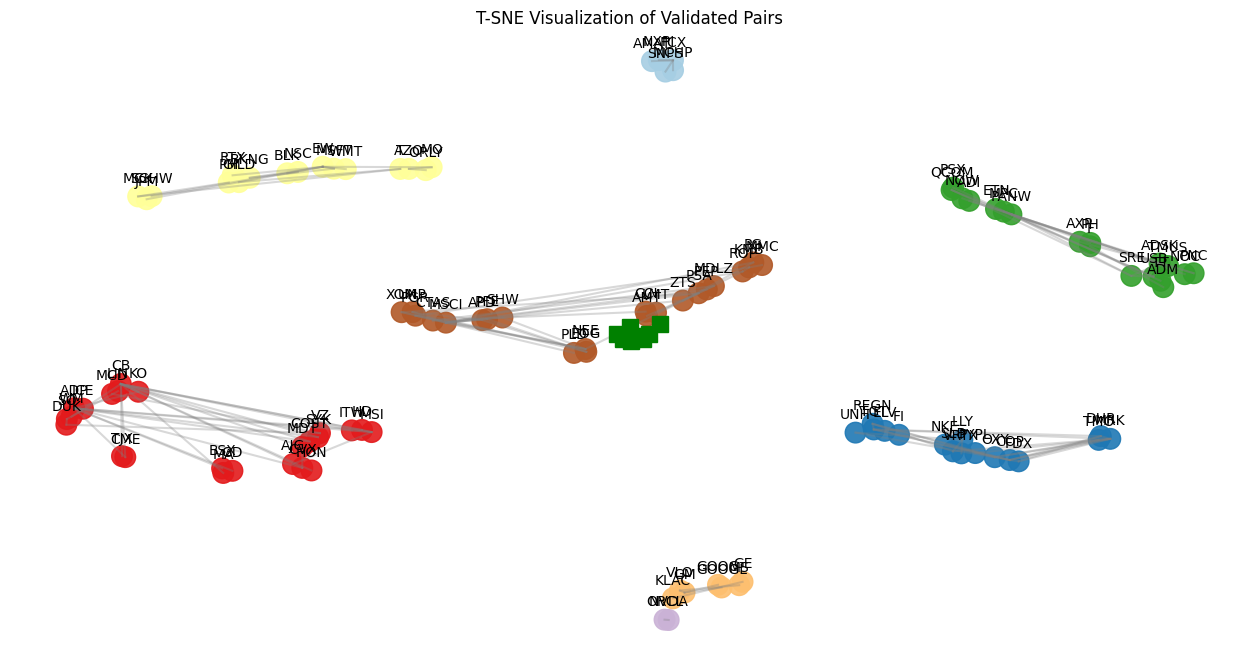

In [202]:
from sklearn.manifold import TSNE
import matplotlib.cm as cm
stocks = np.unique(pairs)
X_df = pd.DataFrame(index=X.index, data=X).T
in_pairs_series = clustered_series.loc[stocks]
stocks = list(np.unique(pairs))
X_pairs = X_df.T.loc[stocks]
X_tsne = TSNE(learning_rate=50, perplexity=3, random_state=1337).fit_transform(X_pairs)
plt.figure(1, facecolor='white', figsize=(16, 8))
plt.clf()
plt.axis('off')
for pair in pairs:
    # print(pair[0])
    ticker1 = pair[0]
    loc1 = X_pairs.index.get_loc(pair[0])
    x1, y1 = X_tsne[loc1, :]
    # print(ticker1, loc1)

    ticker2 = pair[0]
    loc2 = X_pairs.index.get_loc(pair[1])
    x2, y2 = X_tsne[loc2, :]

    plt.plot([x1, x2], [y1, y2], 'k-', alpha=0.3, c='gray');

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=220, alpha=0.9, c=in_pairs_series.values, cmap=cm.Paired)
plt.title('T-SNE Visualization of Validated Pairs');


# zip joins x and y coordinates in pairs
for x, y, name in zip(X_tsne[:, 0], X_tsne[:, 1], X_pairs.index):
    label = name

    plt.annotate(label,  # this is the text
                 (x, y),  # this is the point to label
                 textcoords="offset points",  # how to position the text
                 xytext=(0, 10),  # distance from text to points (x,y)
                 ha='center')  # horizontal alignment can be left, right or center

plt.plot(centroids[:, 0], centroids[:, 1], 'sg', markersize=11)
plt.show()